# TimeTok Visualization

This notebook demonstrates the TimeTok tokenization and reconstruction visualization.

In [9]:
import os, sys, json, math, glob, pickle
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from types import SimpleNamespace
from hydra.utils import instantiate

# --- Path setup (relative to notebook location) ---
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
TOKENIZER_DIR = os.path.dirname(NOTEBOOK_DIR)  # 00_Hierarchical_Tokenizer
REPO_DIR = os.path.dirname(TOKENIZER_DIR)  # TimeTok_Repo

sys.path.insert(0, REPO_DIR)
sys.path.insert(0, TOKENIZER_DIR)

from utils.misc import detect_bf16_support, get_bf16_context, get_generator
from utils.demo import imgs_from_urls, denormalize, batch_to_pil
import torchvision.transforms.functional as TF

enable_bf16 = detect_bf16_support()

from data.UCR_data_factory import ucr_data_provider
from data.Nasdaq_factory import nasdaq_data_provider
from TimeTok_wrapper import TimeTok

In [10]:
# --- Configuration ---
DATASET = "ECG5000"   
TOKENIZER_DATASET = "ECG5000"

# Paths (relative to repository structure)
DATA_DIR = os.path.join(REPO_DIR, "data")
UCR_ROOT = os.path.join(DATA_DIR, "UCRConverted")
CKPT_DIR = os.path.join(REPO_DIR, "03_Shared", "tokenizer_weights", TOKENIZER_DATASET)

In [ ]:
# --- Load data ---
# Option 1: UCR dataset
ns = SimpleNamespace(dataset=DATASET, data_root=UCR_ROOT, root_path=UCR_ROOT,
                     num_workers=0, seq_len=None, seed=42)
train_ls, val_ls, _, param = ucr_data_provider(ns, shuffle_train=False)
train_loader = train_ls[0]
val_loader = val_ls[0]

# # Option 2: Nasdaq dataset
# nasdaq_path = os.path.join(DATA_DIR, "Nasdaq")
# args = SimpleNamespace(ucr_root=nasdaq_path, batch_size=32)
# train_loader, val_loader, test_loader, param = nasdaq_data_provider(args.ucr_root, args.batch_size, shuffle_train=False)

In [ ]:
# --- Load checkpoint ---
best_list = sorted(glob.glob(os.path.join(CKPT_DIR, "TimeTok_best_val_epoch*.pt")))
assert len(best_list) > 0, f"No best checkpoint found: {CKPT_DIR}"
BEST_CKPT = max(best_list, key=os.path.getmtime)

CFG_PATH = os.path.join(CKPT_DIR, "config_snapshot.json")
assert os.path.isfile(CFG_PATH), f"config_snapshot.json not found: {CFG_PATH}"

print("BEST_CKPT:", BEST_CKPT)

# --- Load cfg + instantiate ---
with open(CFG_PATH, "r") as f:
    cfg = json.load(f)

timetok: TimeTok = instantiate(cfg)

# --- Load checkpoint + move to device ---
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
state = torch.load(BEST_CKPT, map_location=device)
timetok.load_state_dict(state)
timetok = timetok.to(device).eval()

In [13]:
# --- Utility functions: padding / unpadding ---
def pad_to_multiple_L(x, multiple: int):
    """Pad x: [B,C,L] to make L a multiple of `multiple` using reflect pad on the right"""
    L = x.shape[-1]
    need = (multiple - (L % multiple)) % multiple
    if need == 0:
        return x, 0
    return F.pad(x, (0, need), mode="reflect"), need

def unpad_L(x, unpad_right: int):
    """Remove right padding from x"""
    if unpad_right == 0:
        return x
    return x[..., :-unpad_right]

In [14]:
def plot_flexible_length_reconsts(imgs, k_keep_list, figscale=3.0, seed=None):
    """Plot reconstructions with varying number of tokens kept"""
    
    # Minimum padding: multiple of Pz
    def pad_to_multiple_L(x, multiple):
        L = x.shape[-1]
        need = (multiple - (L % multiple)) % multiple
        if need == 0:
            return x, 0
        import torch.nn.functional as F
        return F.pad(x, (0, need), mode="reflect"), need

    imgs, unpad_right = pad_to_multiple_L(imgs, multiple=Pz)
    B, C, L0 = imgs.shape

    # Tokenize images once
    with get_bf16_context(enable_bf16):
        tokens_list = timetok.tokenize(imgs)  # List of [1, 256] discrete token sequences

    # Detokenize various subsequences
    all_reconst = {}
    for k_keep in k_keep_list:
        # Simply truncate the token sequences from the right
        subseq_list = [seq[:, :k_keep].clone() for seq in tokens_list]
        with get_bf16_context(enable_bf16):
            generator = get_generator(seed=seed, device=device)
            all_reconst[k_keep] = timetok.detokenize(
                subseq_list, timesteps=25, 
                guidance_scale=1, perform_norm_guidance=True, ts_image_sizes=L0,
                generator=generator, verbose=False,
            )

    x_plot = unpad_L(imgs, unpad_right)

    # Line plot
    ncols = len(k_keep_list) + 1
    fig, axes = plt.subplots(B, ncols, figsize=(figscale * ncols, figscale * B), squeeze=False)
    for i in range(B):
        for j, k in enumerate(k_keep_list):
            ax = axes[i, j]
            y = unpad_L(all_reconst[k][i, 0], unpad_right)
            ax.plot(y.detach().cpu().numpy(), color="#1c7ed6", lw=1.5)
            ax.set_title(f"{k} token" + ("" if k == 1 else "s"), fontsize=12)
            ax.set_xticks([])
            ax.set_yticks([])
        ax = axes[i, -1]
        y = x_plot[i, 0] if C == 1 else x_plot[i].mean(0)
        ax.plot(y.detach().cpu().numpy(), color="#2b8a3e", lw=1.5)
        ax.set_title("Ground Truth", fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])
    plt.tight_layout()
    plt.show()

    return x_plot, all_reconst

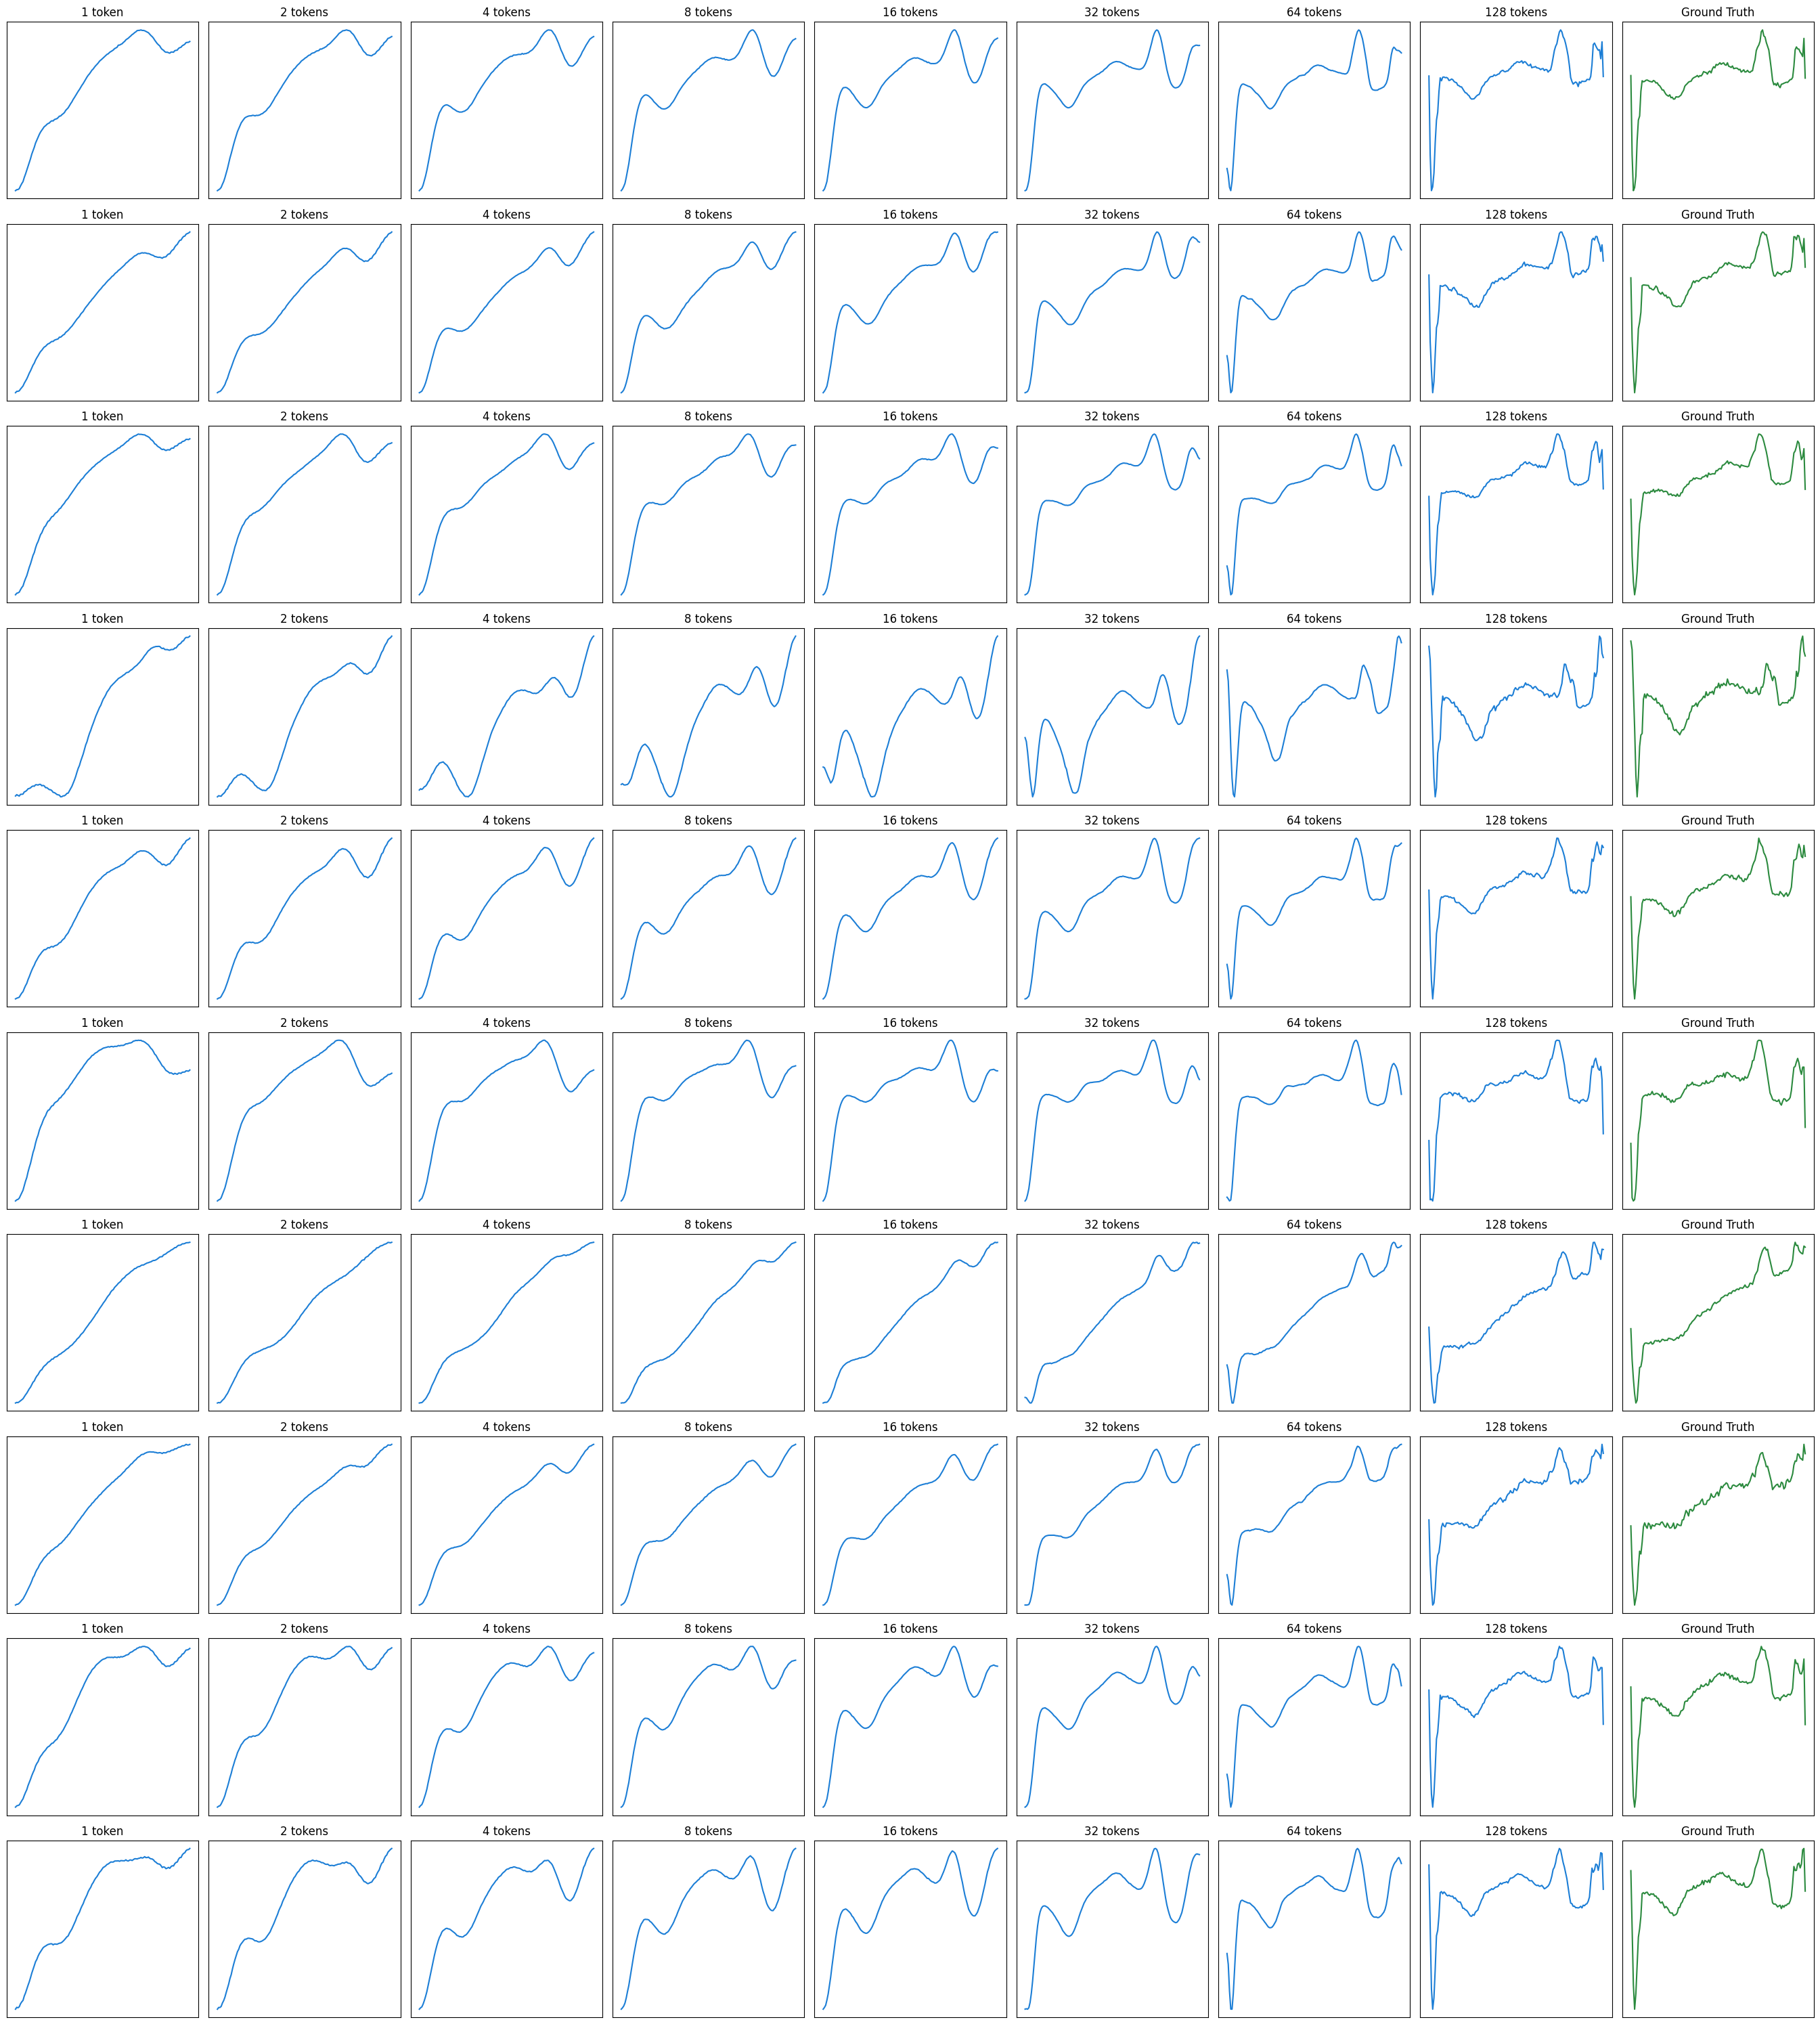

In [15]:
# --- Reconstruction demo: sample from validation set ---
batch = next(iter(val_loader))
x = batch[0] if isinstance(batch, (list, tuple)) else batch  # [B,C,L]
x = x.to(device)[:10]

k_keep_list = [1, 2, 4, 8, 16, 32, 64, 128]
x_plot_val, all_reconst_val = plot_flexible_length_reconsts(x, k_keep_list, seed=0)